# This is the file for my Artifical intelligence class assignment 2 - "Search!!"

In [174]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as sk
from sklearn.metrics import r2_score, mean_squared_error

Should be making a random forest regressor method

In [175]:
dataset = pd.read_csv('student.csv')
#x = dataset.iloc[:, 3:-2].values # removes first 3 and last 2 columns
x = dataset.iloc[:, [3, 4, 5, 13]].values
y = dataset.iloc[:, -2] # removes second last column
#print(y)
x

array([[ 4.35,  3.63,  3.38, 57.21],
       [ 6.14,  6.58,  5.48, 91.27],
       [ 4.98,  3.26,  4.83, 63.14],
       ...,
       [ 9.36,  4.33,  2.94, 73.18],
       [ 0.74,  4.44,  3.15, 77.02],
       [ 3.64,  6.35,  8.68, 40.08]], shape=(20000, 4))

### Splitting the dataset into training set and test set

In [176]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

### Feature Scaling (so magnitude of variables doesn't cause improper impact)

In [177]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

### Training the Random Forest Regressor model on the Training set

In [178]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 15, random_state = 0)
regressor.fit(x_train, y_train)
y_pred = regressor.predict(x_test)



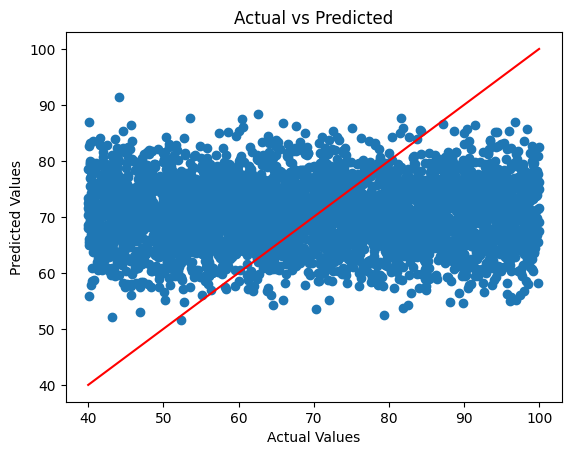

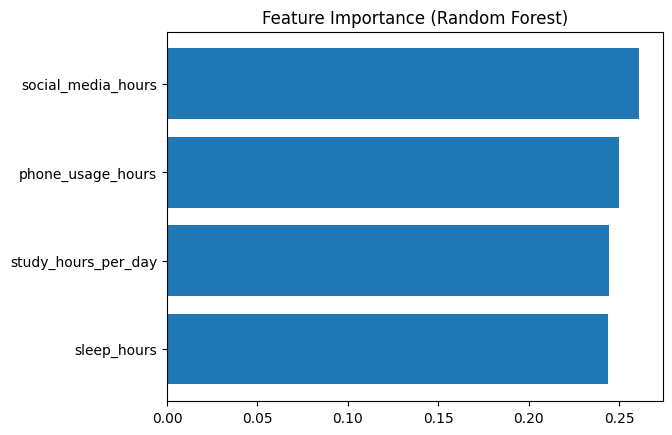

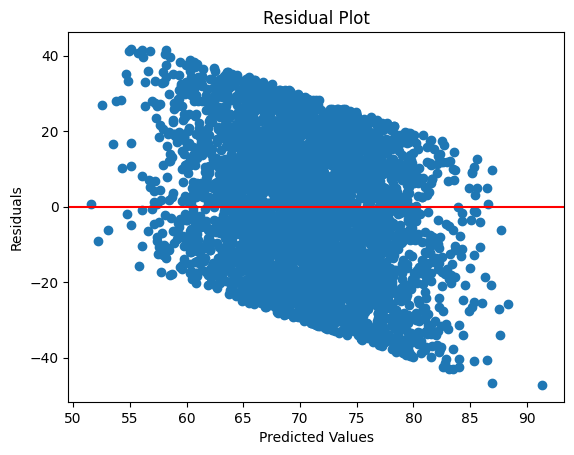

In [179]:
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         color='red')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

import pandas as pd
import matplotlib.pyplot as plt

importances = regressor.feature_importances_
feature_names = dataset.columns[3:-2]  # adjust if necessary

# Sort by importance
indices = importances.argsort()

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("Feature Importance (Random Forest)")
plt.show()

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()